In [4]:
device = torch.device('cpu')  
print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cpu
PyTorch: 2.1.0+cpu


In [4]:
import sys
print(sys.executable)
import torch
print(torch.__version__)

c:\Users\anjal\Downloads\Genie-Task\gsoc_env\Scripts\python.exe
2.1.0+cpu


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve

In [5]:
import os
file_path = r"C:/Users/anjal/Downloads/Genie-Task/data/quark-gluon_data-set_n139306 (1).hdf5"
print("File exists:", os.path.exists(file_path))

import h5py
with h5py.File(file_path, 'r') as f:
    print("Keys:", list(f.keys()))
    print("X_jets shape:", f['X_jets'].shape)

File exists: True
Keys: ['X_jets', 'm0', 'pt', 'y']
X_jets shape: (139306, 125, 125, 3)


In [6]:
def image_to_pointcloud(image, threshold=0.0):
    mask = np.any(image > threshold, axis=-1)
    coords = np.argwhere(mask)
    if len(coords) == 0:
        return np.zeros((1, 5), dtype=np.float32)
    x = coords[:, 0] / 124.0
    y = coords[:, 1] / 124.0
    ecal   = image[coords[:, 0], coords[:, 1], 0]
    hcal   = image[coords[:, 0], coords[:, 1], 1]
    tracks = image[coords[:, 0], coords[:, 1], 2]
    point_cloud = np.stack([x, y, ecal, hcal, tracks], axis=1)
    return point_cloud.astype(np.float32)

In [7]:
class JetGraphDataset(Dataset):
    def __init__(self, X, y, max_nodes=100):  # 100 nodes CPU ke liye
        self.X = X
        self.y = y
        self.max_nodes = max_nodes

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]
        pc = image_to_pointcloud(image)
        if len(pc) > self.max_nodes:
            energy = pc[:, 2] + pc[:, 3] + pc[:, 4]
            top_idx = np.argsort(energy)[-self.max_nodes:]
            pc = pc[top_idx]
        pad_size = self.max_nodes - len(pc)
        if pad_size > 0:
            pc = np.vstack([pc, np.zeros((pad_size, 5), dtype=np.float32)])
        return torch.tensor(pc, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

In [8]:
print("Loading data...")
with h5py.File(file_path, 'r') as f:
    X_data = f['X_jets'][:5000] 
    y_data = f['y'][:5000]
print(f"Loaded! Shape: {X_data.shape}")

indices = np.random.permutation(5000)
train_idx = indices[:4000]
val_idx   = indices[4000:]

train_ds = JetGraphDataset(X_data[train_idx], y_data[train_idx])
val_ds   = JetGraphDataset(X_data[val_idx],   y_data[val_idx])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Loading data...
Loaded! Shape: (5000, 125, 125, 3)
Train: 4000 | Val: 1000


In [9]:
class GNNClassifier(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64):
        super(GNNClassifier, self).__init__()
        self.lin1 = nn.Linear(input_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.lin3 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1  = nn.BatchNorm1d(hidden_dim)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.bn3  = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        B, N, _ = x.shape
        x = x.view(B * N, -1)
        x = F.relu(self.bn1(self.lin1(x)))
        x = F.relu(self.bn2(self.lin2(x)))
        x = F.relu(self.bn3(self.lin3(x)))
        x = x.view(B, N, -1)
        mean_pool = x.mean(dim=1)
        max_pool  = x.max(dim=1).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=-1)).squeeze(-1)

model_gnn = GNNClassifier().to(device)
print(f"Baseline GNN params: {sum(p.numel() for p in model_gnn.parameters()):,}")

Baseline GNN params: 17,409


In [10]:
class NonLocalBlock(nn.Module):
    def __init__(self, in_channels):
        super(NonLocalBlock, self).__init__()
        self.inter_channels = in_channels // 2
        self.theta = nn.Linear(in_channels, self.inter_channels)
        self.phi   = nn.Linear(in_channels, self.inter_channels)
        self.g     = nn.Linear(in_channels, self.inter_channels)
        self.out   = nn.Linear(self.inter_channels, in_channels)
        self.bn    = nn.BatchNorm1d(in_channels)

    def forward(self, x):
        B, N, C = x.shape
        theta = self.theta(x)
        phi   = self.phi(x)
        g     = self.g(x)
        attn  = F.softmax(torch.bmm(theta, phi.transpose(1, 2)) / (self.inter_channels ** 0.5), dim=-1)
        out   = self.out(torch.bmm(attn, g)) + x
        return self.bn(out.view(B*N, C)).view(B, N, C)

class NonLocalGNN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64):
        super(NonLocalGNN, self).__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.lin1      = nn.Linear(hidden_dim, hidden_dim)
        self.bn1       = nn.BatchNorm1d(hidden_dim)
        self.lin2      = nn.Linear(hidden_dim, hidden_dim)
        self.bn2       = nn.BatchNorm1d(hidden_dim)
        self.nonlocal1 = NonLocalBlock(hidden_dim)
        self.nonlocal2 = NonLocalBlock(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        B, N, _ = x.shape
        x = self.input_proj(x.view(B*N, -1)).view(B, N, -1)
        x = self.nonlocal1(x)
        x = F.relu(self.bn1(self.lin1(x.view(B*N, -1)))).view(B, N, -1)
        x = self.nonlocal2(x)
        x = F.relu(self.bn2(self.lin2(x.view(B*N, -1)))).view(B, N, -1)
        mean_pool = x.mean(dim=1)
        max_pool  = x.max(dim=1).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=-1)).squeeze(-1)

model_nl = NonLocalGNN().to(device)
print(f"Non-local GNN params: {sum(p.numel() for p in model_nl.parameters()):,}")

Non-local GNN params: 34,369


In [11]:
criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return total_loss/len(loader), roc_auc_score(all_labels, all_preds), all_preds, all_labels

In [12]:
num_epochs = 10
base_aucs, nl_aucs = [], []

# Baseline
print("-" * 50)
print("Training Baseline GNN...")
print("=" * 50)
opt_gnn = torch.optim.Adam(model_gnn.parameters(), lr=1e-3, weight_decay=1e-4)
for epoch in range(num_epochs):
    tl = train_epoch(model_gnn, train_loader, opt_gnn)
    vl, auc, _, _ = eval_epoch(model_gnn, val_loader)
    base_aucs.append(auc)
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | AUC: {auc:.4f}")

# Non-local
print("\n" + "-" * 50)
print("Training Non-local GNN...")
print("=" * 50)
opt_nl = torch.optim.Adam(model_nl.parameters(), lr=1e-3, weight_decay=1e-4)
for epoch in range(num_epochs):
    tl = train_epoch(model_nl, train_loader, opt_nl)
    vl, auc, _, _ = eval_epoch(model_nl, val_loader)
    nl_aucs.append(auc)
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | AUC: {auc:.4f}")

print("\nDone!")

--------------------------------------------------
Training Baseline GNN...
Epoch [ 1/10] | Loss: 0.6417 | AUC: 0.7102
Epoch [ 2/10] | Loss: 0.6201 | AUC: 0.7202
Epoch [ 3/10] | Loss: 0.6149 | AUC: 0.7248
Epoch [ 4/10] | Loss: 0.6140 | AUC: 0.7309
Epoch [ 5/10] | Loss: 0.6069 | AUC: 0.7369
Epoch [ 6/10] | Loss: 0.5993 | AUC: 0.7407
Epoch [ 7/10] | Loss: 0.5941 | AUC: 0.7450
Epoch [ 8/10] | Loss: 0.5863 | AUC: 0.7502
Epoch [ 9/10] | Loss: 0.5841 | AUC: 0.7551
Epoch [10/10] | Loss: 0.5891 | AUC: 0.7586

--------------------------------------------------
Training Non-local GNN...
Epoch [ 1/10] | Loss: 0.6543 | AUC: 0.7082
Epoch [ 2/10] | Loss: 0.6180 | AUC: 0.7159
Epoch [ 3/10] | Loss: 0.6097 | AUC: 0.7198
Epoch [ 4/10] | Loss: 0.6027 | AUC: 0.7319
Epoch [ 5/10] | Loss: 0.5974 | AUC: 0.7446
Epoch [ 6/10] | Loss: 0.5900 | AUC: 0.7583
Epoch [ 7/10] | Loss: 0.5812 | AUC: 0.7594
Epoch [ 8/10] | Loss: 0.5763 | AUC: 0.7370
Epoch [ 9/10] | Loss: 0.5694 | AUC: 0.7718
Epoch [10/10] | Loss: 0.5612 

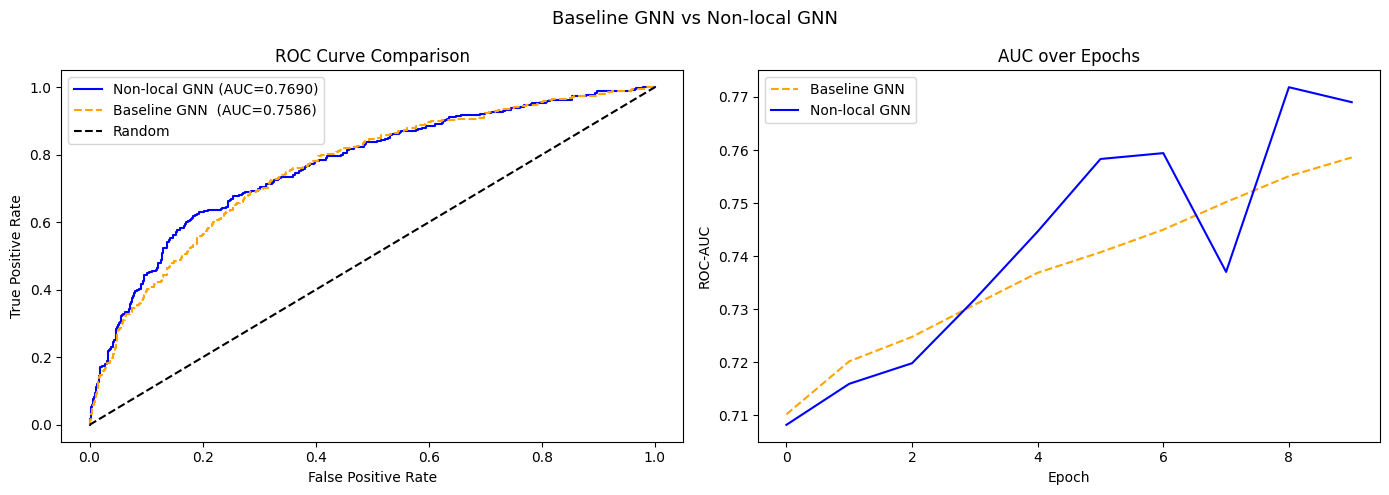

Baseline GNN  AUC: 0.7586
Non-local GNN AUC: 0.7690
Improvement:       1.04%


In [13]:
_, base_auc, base_preds, base_labels = eval_epoch(model_gnn, val_loader)
_, nl_auc,   nl_preds,   nl_labels   = eval_epoch(model_nl,  val_loader)

fpr_b, tpr_b, _ = roc_curve(base_labels, base_preds)
fpr_n, tpr_n, _ = roc_curve(nl_labels,   nl_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr_n, tpr_n, label=f'Non-local GNN (AUC={nl_auc:.4f})', color='blue')
ax1.plot(fpr_b, tpr_b, label=f'Baseline GNN  (AUC={base_auc:.4f})', color='orange', linestyle='--')
ax1.plot([0,1],[0,1],'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend()

ax2.plot(base_aucs, label='Baseline GNN',  color='orange', linestyle='--')
ax2.plot(nl_aucs,   label='Non-local GNN', color='blue')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('AUC over Epochs')
ax2.legend()

plt.suptitle('Baseline GNN vs Non-local GNN', fontsize=13)
plt.tight_layout()

save_dir = r"C:\Users\anjal\Downloads\Genie-Task\specific_task"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'comparison_roc.png'), dpi=150)
plt.show()

print(f"Baseline GNN  AUC: {base_auc:.4f}")
print(f"Non-local GNN AUC: {nl_auc:.4f}")
print(f"Improvement:       {(nl_auc - base_auc)*100:.2f}%")